# System Metrics Study

In [43]:
from pathlib import Path
import pandas as pd
import numpy as np

## Experiment Configuration

In [20]:
# experiment = "system_metrics_study"
experiment = "logic_study"

In [21]:
dataset = "darpa2000"
scenario = "s1_inside"


In [30]:
experiment_dir = f"../../experiments/{dataset}/{scenario}/{experiment}/deepproblog"
monitor_dir = Path(f"{experiment_dir}/monitor")
file_paths = list(monitor_dir.iterdir())

In [48]:
def load_monitor_csv(file_path):
    try:
        df = pd.read_csv(file_path, parse_dates=['ts'])
    except Exception as e:
        print(f"Error loading {file_path}: {e}")
        df = pd.DataFrame()
    
    if 'ts' in df.columns:
        df['ts'] = pd.to_datetime(df['ts'], format='%Y-%m-%dT%H:%M:%S.%f+00:00Z')
        df['t_s'] = (df['ts'] - df['ts'].iloc[0]).dt.total_seconds()
    else:
        print(f"'ts' column not found in {file_path}.")
    
    return df

In [49]:
def summarize_memory(df, col='rss_mb'):
    secs = df['t_s'].values
    vals = df[col].values
    peak = np.nanmax(vals)
    peak_idx = np.nanargmax(vals)
    time_to_peak = secs[peak_idx]
    auc = np.trapezoid(vals, secs)  # MB·s
    median = np.nanmedian(vals)
    p90 = np.nanpercentile(vals, 90)
    p99 = np.nanpercentile(vals, 99)
    # linear slope MB/s (robust: use first N seconds to estimate steady growth)
    if len(secs) > 5:
        coeff = np.polyfit(secs, vals, 1)[0]
    else:
        coeff = np.nan
    return {
        'peak_mb': float(peak),
        'time_to_peak_s': float(time_to_peak),
        'auc_mb_s': float(auc),
        'median_mb': float(median),
        'p90_mb': float(p90),
        'p99_mb': float(p99),
        'slope_mb_per_s': float(coeff),
    }


=== darpa_temp_context_endtoend_base_w10_1000b1000a_0.001lr_20260525_172339_train_metrics === 
Experiment: train


/tmp/ipykernel_142467/176223241.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df = pd.read_csv(file_path, parse_dates=['ts'])


peak_mb             1292.910156
time_to_peak_s       143.300360
auc_mb_s          286409.363065
median_mb           1292.773438
p90_mb              1292.910156
p99_mb              1292.910156
slope_mb_per_s         0.286926
dtype: float64

=== darpa_temp_context_endtoend_base_w10_1000b1000a_0.001lr_20260525_172339_test_metrics === 
Experiment: test
peak_mb           5.908738e+03
time_to_peak_s    2.987379e+02
auc_mb_s          1.061187e+06
median_mb         3.467605e+03
p90_mb            5.202378e+03
p99_mb            5.795514e+03
slope_mb_per_s    1.349962e+01
dtype: float64


/tmp/ipykernel_142467/176223241.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df = pd.read_csv(file_path, parse_dates=['ts'])


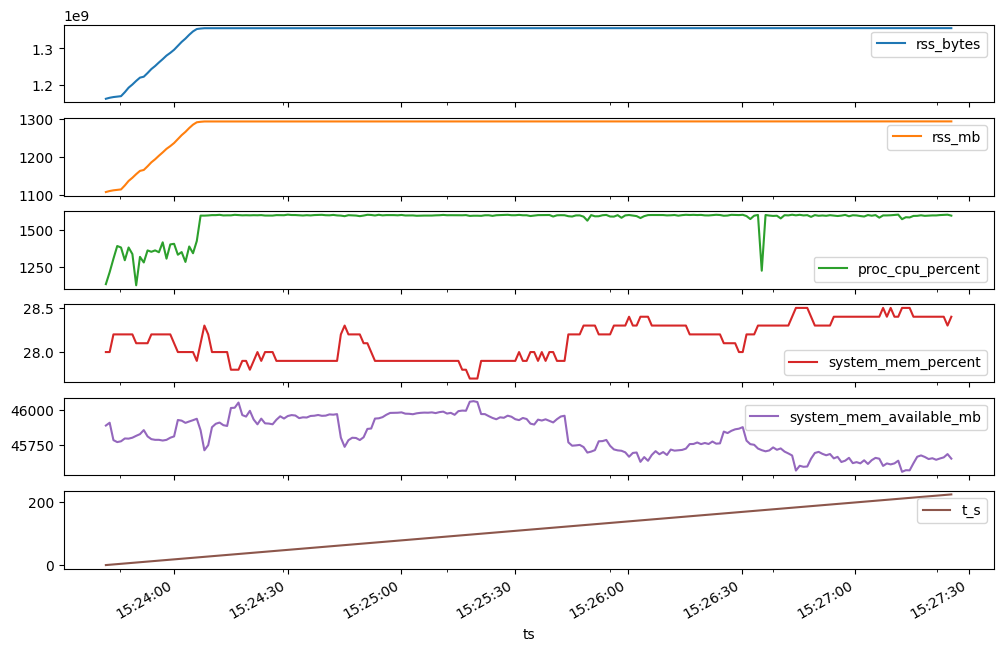

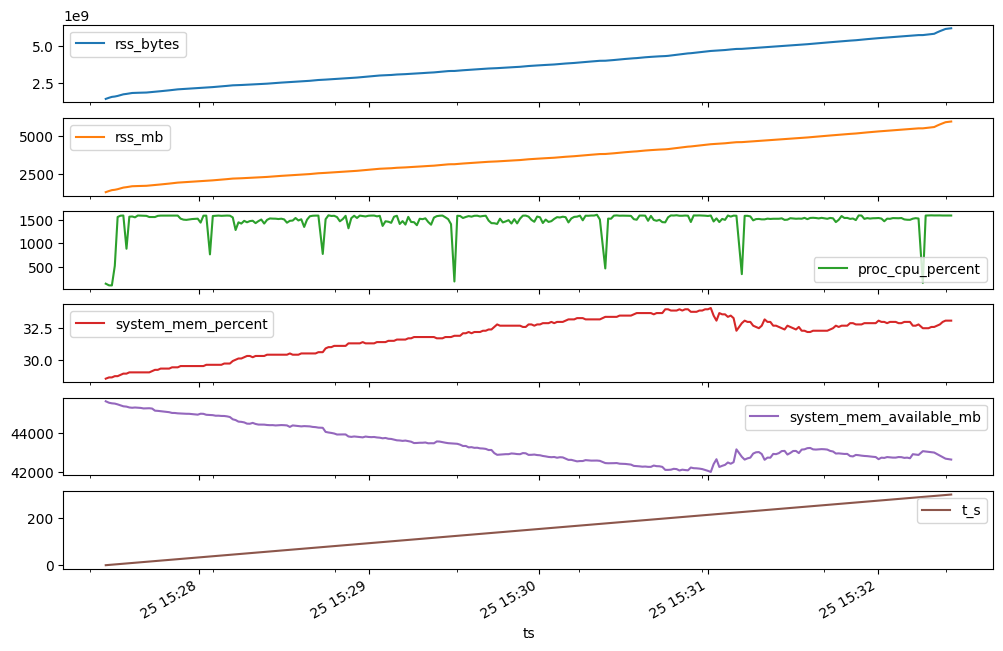

In [59]:
for file_path in file_paths:
    experiment_name = file_path.stem
    print(f"\n=== {experiment_name} === ")
    exp = experiment_name.split("_")[-2]
    print(f"Experiment: {exp}")
    df = load_monitor_csv(file_path)
    df.set_index('ts').plot(subplots=True, figsize=(12,8))
    summary = summarize_memory(df)
    print(pd.Series(summary))